**NIFTY50 BASELINE OHLCV - OPEN PRICE**

In [1]:
# Numerical Computation and Data Manipulation
import numpy as np
import pandas as pd
import math

# Yahoo Finance API
import yfinance as yf

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Scaling and Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filter Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Configuration
tickers = {"Nifty 50": "^NSEI"}
horizons = {
    "5_Years": "2021-06-01",
    "10_Years": "2016-06-01",
    "20_Years": "2006-06-01"
}
end_date = "2026-06-01"

models = {
    "Naive Persistence": None,
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Elastic Net": ElasticNet(),
    "SGDRegressor": SGDRegressor(),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

In [3]:
def prep_raw_data_for_open(raw_data):
    df = raw_data.copy()
    
    df["Target"] = df["Open"].shift(-1)
    
    # Raw Features Only
    feature_cols = ["Open", "High", "Low", "Close", "Volume"]
        
    # Clean data
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    clean_df = df[feature_cols + ["Target"]].dropna()
    
    X = clean_df[feature_cols]
    y = clean_df["Target"]
    
    return X, y

In [4]:
train_results_dfs = {}
test_results_dfs = {}
plot_data_store = {} 

for company, ticker in tickers.items():
    print(f"Downloading data for: {company} ({ticker})")
    raw_data = yf.download(ticker, start="2005-01-01", end=end_date, progress=False)
    
    for horizon_name, start_date in horizons.items():
        horizon_raw = raw_data.loc[start_date:end_date]
        
        # Prepare data
        X, y = prep_raw_data_for_open(horizon_raw)
        
        # Chronological Split (80/20)
        split = int(len(X) * 0.8)
        X_train, X_test = X.iloc[:split], X.iloc[split:]
        y_train, y_test = y.iloc[:split], y.iloc[split:]
        
        # Setup dictionary for plotting
        dict_key = (company, horizon_name)
        plot_data_store[dict_key] = {'y_test': y_test, 'predictions': {}}
        
        current_train_metrics = []
        current_test_metrics = []
        
        for model_name, model in models.items():
            if model_name == "Naive Persistence":
                # Naive Persistence method
                train_pred = X_train.iloc[:, 0].values
                test_pred = X_test.iloc[:, 0].values
            else:
                # All other models use the StandardScaler pipeline
                pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
                pipe.fit(X_train, y_train)
                train_pred = pipe.predict(X_train)
                test_pred = pipe.predict(X_test)
            
            plot_data_store[dict_key]['predictions'][model_name] = test_pred
            
            current_train_metrics.append({
                "Model": model_name,
                "Train_MAE": mean_absolute_error(y_train, train_pred),
                "Train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
                "Train_R2": r2_score(y_train, train_pred)
            })
            
            current_test_metrics.append({
                "Model": model_name,
                "Test_MAE": mean_absolute_error(y_test, test_pred),
                "Test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
                "Test_R2": r2_score(y_test, test_pred)
            })
            
        # Save dataframes sorted by R2
        train_results_dfs[(company, horizon_name)] = pd.DataFrame(current_train_metrics).sort_values(by="Train_R2", ascending=False, ignore_index=True)
        test_results_dfs[(company, horizon_name)] = pd.DataFrame(current_test_metrics).sort_values(by="Test_R2", ascending=False, ignore_index=True)

print("\nExecution Complete!")


Execution Complete!


In [5]:
print("--- Train 5 Years (Open Price) ---")
display(train_results_dfs[("Nifty 50", "5_Years")])
print("\n--- Test 5 Years (Open Price) ---")
display(test_results_dfs[("Nifty 50", "5_Years")])

print("\n--- Train 10 Years (Open Price) ---")
display(train_results_dfs[("Nifty 50", "10_Years")])
print("\n--- Test 10 Years (Open Price) ---")
display(test_results_dfs[("Nifty 50", "10_Years")])

print("\n--- Train 20 Years (Open Price) ---")
display(train_results_dfs[("Nifty 50", "20_Years")])
print("\n--- Test 20 Years (Open Price) ---")
display(test_results_dfs[("Nifty 50", "20_Years")])

--- Train 5 Years (Open Price) ---


,Model,Train_MAE,Train_RMSE,Train_R2
0,DecisionTree,0.000000,0.000000,1.000000
1,XGBRegressor,16.422159,23.137676,0.999940
2,RandomForest,31.144898,45.909719,0.999764
3,GradientBoosting,52.022461,74.262586,0.999383
4,LinearRegression,69.338637,105.736082,0.998750
5,Ridge,76.816330,113.849204,0.998550
6,Lasso,77.900130,115.146405,0.998517
7,SGDRegressor,90.972985,130.152298,0.998105
8,K-Nearest Neighbors,114.045034,178.521656,0.996436
9,Naive Persistence,135.752468,187.694212,0.996060



--- Test 5 Years (Open Price) ---


,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,90.093148,159.617771,0.965788
1,Ridge,101.303605,172.342241,0.960115
2,Lasso,101.932725,172.814889,0.959896
3,GradientBoosting,117.648876,183.137911,0.954962
4,RandomForest,117.563603,183.759666,0.954656
5,SGDRegressor,116.564963,187.604419,0.952739
6,XGBRegressor,148.713958,212.326558,0.939462
7,DecisionTree,143.543143,218.708933,0.935768
8,Naive Persistence,164.241626,236.804943,0.924699
9,AdaBoostRegressor,223.221524,288.327610,0.888367



--- Train 10 Years (Open Price) ---


...

,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,86.056804,150.889187,0.976978
1,Ridge,100.716003,166.188812,0.972072
2,SGDRegressor,116.682432,182.584791,0.966290
3,Lasso,125.560406,192.285128,0.962613
4,Naive Persistence,167.647324,241.392885,0.941078
5,Elastic Net,1201.081463,1217.490815,-0.498862
6,DecisionTree,1544.021120,1789.272565,-2.237302
7,RandomForest,1588.530246,1832.487511,-2.395567
8,GradientBoosting,1603.238491,1846.003045,-2.445839
9,XGBRegressor,1783.100707,2013.585242,-3.099872



--- Train 20 Years (Open Price) ---


,Model,Train_MAE,Train_RMSE,Train_R2
0,DecisionTree,0.000000,0.000000,1.000000
1,RandomForest,13.591003,24.075256,0.999959
2,XGBRegressor,23.205344,33.063363,0.999923
3,GradientBoosting,33.198502,49.375734,0.999828
4,LinearRegression,31.203655,57.766683,0.999765
5,Ridge,37.208369,62.795357,0.999722
6,SGDRegressor,47.516891,74.125851,0.999612
7,K-Nearest Neighbors,46.553150,84.459553,0.999497
8,Lasso,56.111592,84.921788,0.999491
9,Naive Persistence,73.587010,107.931418,0.999178



--- Test 20 Years (Open Price) ---


,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,72.739107,122.952734,0.998170
1,Ridge,83.408510,134.382296,0.997813
2,SGDRegressor,100.074925,152.277800,0.997192
3,Lasso,113.756693,168.581596,0.996559
4,Naive Persistence,142.965283,203.845797,0.994969
5,Elastic Net,1895.221942,1943.093181,0.542828
6,RandomForest,3836.926054,4670.777833,-1.641622
7,GradientBoosting,3837.647490,4671.595776,-1.642547
8,DecisionTree,3878.309859,4705.931743,-1.681535
9,K-Nearest Neighbors,3977.697671,4788.737305,-1.776734


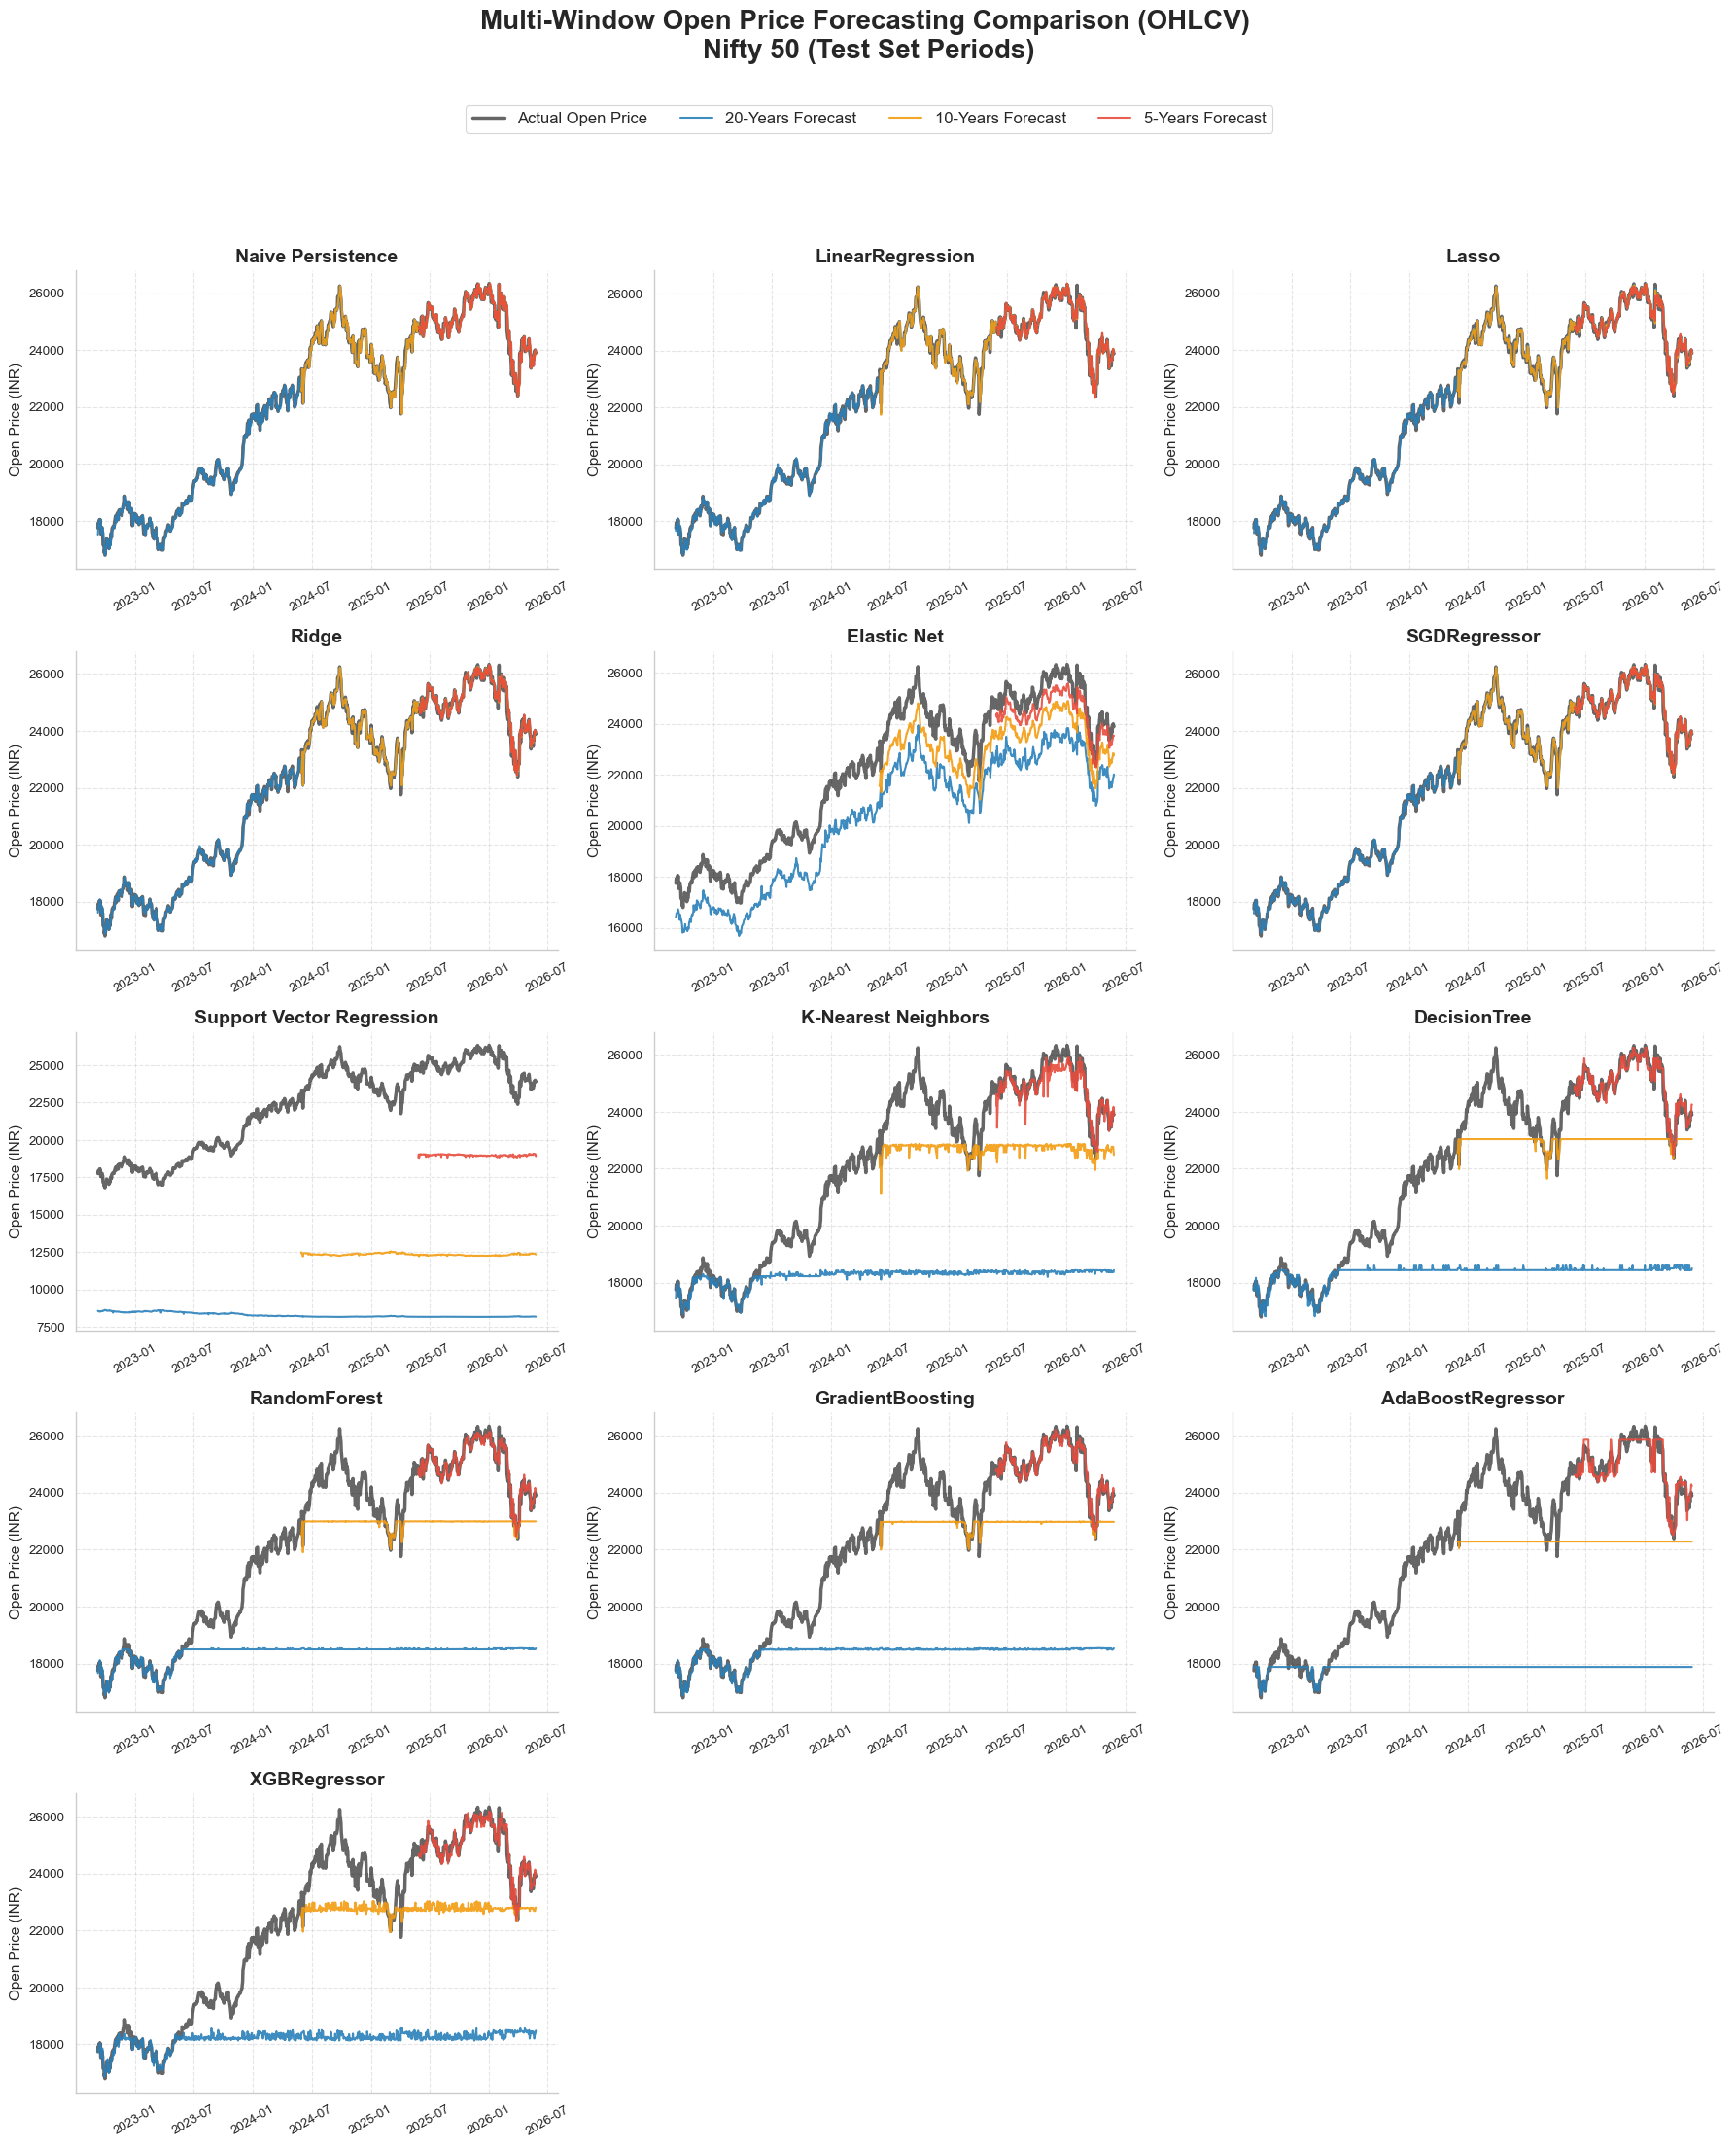

In [6]:
def plot_consolidated_predictions(company_name):
    """
    Plots Actual vs 5-Year, 10-Year, and 20-Year predictions 
    on a single graph for each model.
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    
    n_models = len(models)
    n_cols = 3 
    n_rows = math.ceil(n_models / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows), sharex=False)
    axes = axes.flatten()
    
    fig.suptitle(f"Multi-Window Open Price Forecasting Comparison (OHLCV) \n{company_name} (Test Set Periods)", 
                 fontsize=20, fontweight='bold', y=0.98)
    
    colors = {
        "5_Years": "#e74c3c",  
        "10_Years": "#f39c12", 
        "20_Years": "#2980b9" 
    }
    
    horizon_order = ["20_Years", "10_Years", "5_Years"]
    
    for i, model_name in enumerate(models.keys()):
        ax = axes[i]
        
        # 1. Plot the Actual Prices (Using the longest 20-year test set as the baseline)
        key_20 = (company_name, "20_Years")
        if key_20 in plot_data_store:
            y_actual_20 = plot_data_store[key_20]['y_test']
            ax.plot(y_actual_20.index, y_actual_20.values, color="black", 
                    linewidth=2.5, label="Actual Open Price", alpha=0.6)
            
        # 2. Loop through horizons and plot the predictions
        for horizon_name in horizon_order:
            key = (company_name, horizon_name)
            if key not in plot_data_store: 
                continue
                
            y_test = plot_data_store[key]['y_test']
            y_pred = plot_data_store[key]['predictions'][model_name]
            
            # Create a pandas Series to align the predictions with the real dates
            pred_series = pd.Series(y_pred, index=y_test.index)
            
            label_name = horizon_name.replace("_", "-") + " Forecast"
            ax.plot(pred_series.index, pred_series.values, color=colors[horizon_name], 
                    linewidth=1.5, label=label_name, alpha=0.9)
            
        # Formatting the subplot
        ax.set_title(f"{model_name}", fontsize=14, fontweight='bold')
        ax.set_ylabel("Open Price (INR)", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Make the x-axis dates readable
        ax.tick_params(axis='x', rotation=30)
        sns.despine(ax=ax)
        
    # Remove any empty subplots if the grid isn't perfectly filled
    for j in range(n_models, len(axes)): 
        fig.delaxes(axes[j])
        
    # Extract handles for a single master legend at the top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), 
               ncol=4, frameon=True, fontsize=12)
    
    # Adjust layout to make room for the master title and legend
    plt.tight_layout(rect=[0, 0, 1, 0.91])
    
    # Save the figure in high-res for your paper before showing it
    plt.savefig(f"{company_name}_open_baseline_ohlcv_performance_forecast.png", dpi=300, bbox_inches='tight')
    plt.show()

# Execute the visualization
plot_consolidated_predictions("Nifty 50")